In [1]:
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
def load_data(startdate):

    startdate_dt = datetime.strptime(startdate, '%Y-%m-%d')
    enddate_dt = startdate_dt + timedelta(days=11)
    enddate = enddate_dt.strftime('%Y-%m-%d')

    countries = ['DE', 'FR', 'IT', 'RO']

    c=0
    for country in countries:
        file_path = f'raw_metdesk/wind_{country}_eceps_{startdate}T00_{enddate}T00.csv'
        climate_path = f'raw_metdesk/climate_{country}_{startdate}_{enddate}.csv'
        
        # select the mean of eps
        data = pd.read_csv(file_path)
        data_eceps = data[data['member']== 'mean'].copy()
        data_eceps.drop(columns=['member'], inplace=True)

        climate_data = pd.read_csv(climate_path)

        # column dtg as datetime
        data_eceps['dtg'] = pd.to_datetime(data_eceps['dtg'], format='%Y-%m-%dT%H:%M:%SZ')
        climate_data['dtg'] = pd.to_datetime(climate_data['dtg'], format='%Y-%m-%dT%H:%M:%SZ')
        # rename value by the country
        data_eceps.rename(columns={'value': f'{country}'}, inplace=True)
        climate_data.rename(columns={'value': f'climate_{country}'}, inplace=True)
        # only select full hours of dtg
        data_eceps = data_eceps[data_eceps['dtg'].dt.minute == 0].copy()
        climate_data = climate_data[climate_data['dtg'].dt.minute == 0].copy()
        # set dtg as index
        data_eceps.set_index('dtg', inplace=True)
        climate_data.set_index('dtg', inplace=True)

        # merge data_eceps and climate_data on dtg
        data_eceps = data_eceps.merge(climate_data, left_index=True, right_index=True, how='outer')

        if c == 0:
            data_all = data_eceps
        else:
            data_all = pd.concat([data_all, data_eceps], axis=1)
        c += 1
   
    return data_all

In [3]:
startdate=datetime.today().strftime('%Y-%m-%d')
eceps = load_data(startdate)

In [4]:
eceps

,DE,climate_DE,FR,climate_FR,IT,climate_IT,RO,climate_RO
dtg,,,,,,,,
2025-10-02 00:00:00,8879.97,17203.17,1920.72,4821.31,5173.76,2052.77,708.63,632.35
2025-10-02 01:00:00,8089.17,17203.21,1960.35,4822.38,5420.84,2052.68,691.96,632.44
2025-10-02 02:00:00,7298.37,17203.53,1999.98,4823.78,5667.93,2052.72,675.28,632.49
2025-10-02 03:00:00,6507.57,17204.33,2039.61,4824.76,5915.01,2052.50,658.61,632.50
2025-10-02 04:00:00,7008.10,17204.98,2088.48,4825.62,5998.56,2052.30,760.45,632.57
...,...,...,...,...,...,...,...,...
2025-10-12 20:00:00,21404.81,19453.39,4278.78,5473.49,2229.65,2131.35,820.83,661.34
2025-10-12 21:00:00,20885.71,19467.54,4191.38,5477.33,2209.04,2131.93,798.50,661.39
2025-10-12 22:00:00,20366.61,19480.68,4103.97,5479.87,2188.43,2132.17,776.17,661.40


In [5]:
def plot_data(data):
    """    Plot the data for all countries on different subplots."""

    fig, ax = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
    colors = {'DE': 'orange', 'FR': 'blue', 'IT': 'red', 'RO': 'maroon'}

    for i, country in enumerate(['DE', 'FR', 'IT', 'RO']):
        ax[i].plot(data.index, data[country]/1000, color=colors[country], label=country)
        ax[i].plot(data.index, data[f'climate_{country}']/1000, color=colors[country], linestyle='--', label=f'Climate {country}')
        ax[i].legend()
        ax[i].set_ylabel('Wind Generation (GW)')

        # vertical bar for monday
        for j in range(0, len(data.index), 24):
            if data.index[j].weekday() == 0:
                ax[i].axvline(x=data.index[j], color='gray', linestyle='-', linewidth=0.5)
                # add week number on the right side
                xpad= 0.02
                ax[i].text(data.index[j] + timedelta(hours=1), ax[i].get_ylim()[1]*0.9, f'Week {data.index[j].isocalendar()[1]}',
                           horizontalalignment='left', verticalalignment='center', fontsize=8, color='gray')
                break            

    plt.suptitle(f'EC EPS {data.index[0].strftime("%Y-%m-%d")} 00Z')
    plt.tight_layout()


    plt.show()
        

    

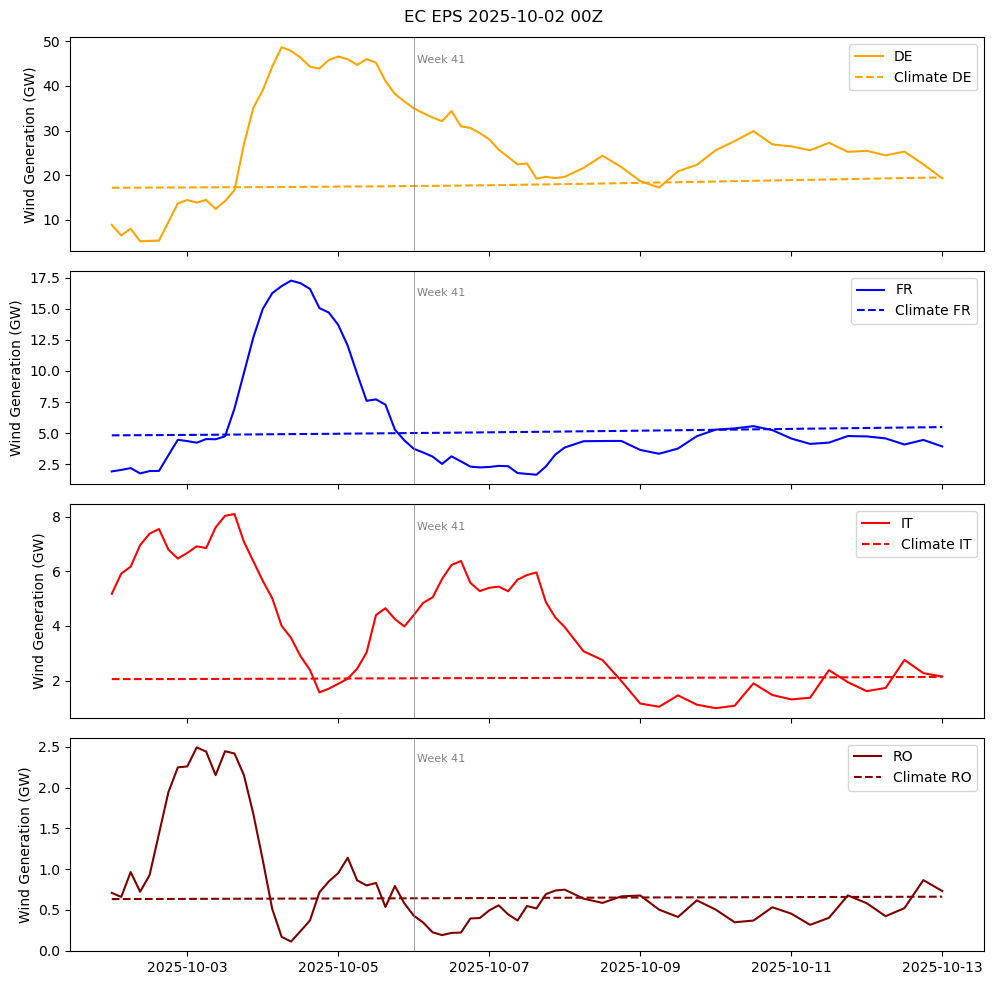

In [6]:
plot_data(eceps)